In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Loading Data


In [2]:
df = pd.read_csv('mental_health_proxy_timeseries.csv')
print(df.shape)
df.head()

(29, 7)


,year,burglary_worry_pct,car_crime_worry_pct,violent_crime_worry_pct,feel_safe_male_pct,feel_safe_female_pct,feel_safe_all_pct
0,1992,19.0000,NaN,NaN,NaN,NaN,NaN
1,1994,26.0000,NaN,NaN,84.0978,45.4771,64.0487
2,1996,22.1255,NaN,NaN,85.0083,52.6589,68.2005
3,1998,19.3000,22.3,24.6,85.0804,51.5994,67.7154
4,2000,19.2000,21.0,23.7,84.9843,52.7326,68.2818


## Cleaning Data

In [3]:
# Drop 2021/2022 COVID gap rows (no survey data)
df = df[~df['year'].isin([2021, 2022])].reset_index(drop=True)

# For Chow test: use annual portion only (2002 onwards, consistent spacing)
df_annual = df[df['year'] >= 2002].copy()

print('Full series:', df.shape)
print('Annual series (2002+):', df_annual.shape)

Full series: (27, 7)
Annual series (2002+): (22, 7)


## Rolling Averages(3 year)

In [4]:
cols = ['burglary_worry_pct', 'car_crime_worry_pct', 'violent_crime_worry_pct',
        'feel_safe_male_pct', 'feel_safe_female_pct', 'feel_safe_all_pct']

for col in cols:
    df[f'{col}_ra3'] = df[col].rolling(window=3, min_periods=2).mean().round(4)

df[['year'] + [c for c in df.columns if '_ra3' in c]]

,year,burglary_worry_pct_ra3,car_crime_worry_pct_ra3,violent_crime_worry_pct_ra3,feel_safe_male_pct_ra3,feel_safe_female_pct_ra3,feel_safe_all_pct_ra3
0,1992,NaN,NaN,NaN,NaN,NaN,NaN
1,1994,22.5000,NaN,NaN,NaN,NaN,NaN
2,1996,22.3752,NaN,NaN,84.5531,49.0680,66.1246
3,1998,22.4752,NaN,NaN,84.7288,49.9118,66.6549
4,2000,20.2085,21.6500,24.1500,85.0243,52.3303,68.0659
5,2002,17.9000,20.2000,23.3667,84.7001,52.4762,68.0278
6,2003,16.4000,18.3000,22.1000,83.6621,52.0923,67.3610
7,2004,14.2000,16.2667,19.6333,83.2019,52.2675,67.2615
8,2005,13.1667,14.9667,17.8000,83.4577,53.4189,67.9869
9,2006,12.4667,14.0000,16.6000,83.7407,54.7926,68.8415


## Raw vs Rolling Average comparison

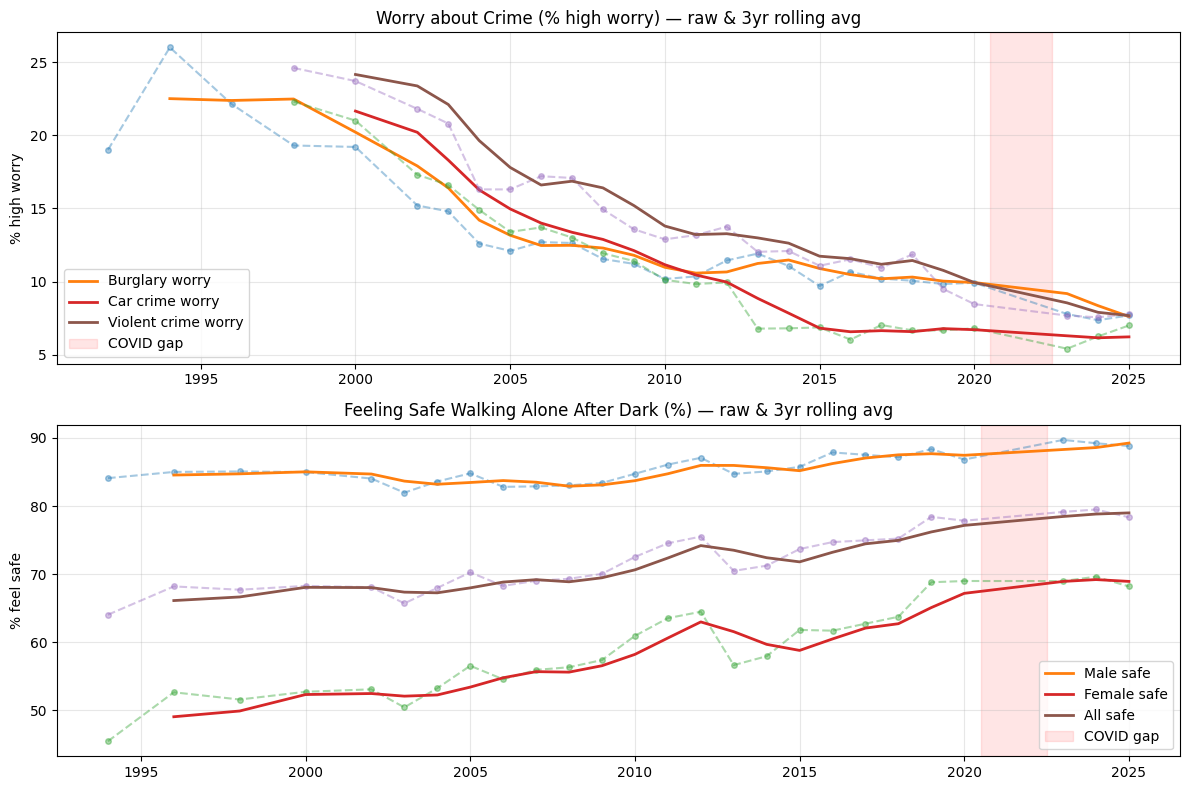

In [5]:
worry_cols  = ['burglary_worry_pct', 'car_crime_worry_pct', 'violent_crime_worry_pct']
safe_cols   = ['feel_safe_male_pct', 'feel_safe_female_pct', 'feel_safe_all_pct']
labels_w    = ['Burglary worry', 'Car crime worry', 'Violent crime worry']
labels_s    = ['Male safe', 'Female safe', 'All safe']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for col, lbl in zip(worry_cols, labels_w):
    axes[0].plot(df['year'], df[col], 'o--', alpha=0.4, markersize=4)
    axes[0].plot(df['year'], df[f'{col}_ra3'], linewidth=2, label=lbl)
axes[0].axvspan(2020.5, 2022.5, color='red', alpha=0.1, label='COVID gap')
axes[0].set_title('Worry about Crime (% high worry) — raw & 3yr rolling avg')
axes[0].set_ylabel('% high worry'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for col, lbl in zip(safe_cols, labels_s):
    axes[1].plot(df['year'], df[col], 'o--', alpha=0.4, markersize=4)
    axes[1].plot(df['year'], df[f'{col}_ra3'], linewidth=2, label=lbl)
axes[1].axvspan(2020.5, 2022.5, color='red', alpha=0.1, label='COVID gap')
axes[1].set_title('Feeling Safe Walking Alone After Dark (%) — raw & 3yr rolling avg')
axes[1].set_ylabel('% feel safe'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rolling_averages.png', dpi=150, bbox_inches='tight')
plt.show()

## Chow Test (Structural Break Detection)

In [6]:
def chow_test(series, years, break_year):
    mask = ~np.isnan(series)
    y = series[mask]; x = years[mask]

    def rss(xs, ys):
        if len(xs) < 3: return np.nan
        slope, intercept, *_ = stats.linregress(xs, ys)
        return np.sum((ys - (slope * xs + intercept)) ** 2)

    m1 = x <= break_year;  m2 = x > break_year
    rss1 = rss(x[m1], y[m1])
    rss2 = rss(x[m2], y[m2])
    rss_p = rss(x, y)

    if np.isnan(rss1) or np.isnan(rss2): return np.nan, np.nan

    k = 2
    n = mask.sum()
    F = ((rss_p - rss1 - rss2) / k) / ((rss1 + rss2) / (n - 2 * k))
    p = 1 - stats.f.cdf(F, k, n - 2 * k)
    return round(F, 4), round(p, 4)


BREAK_YEAR = 2013
y_arr = df_annual['year'].values.astype(float)

results = []
for col in cols:
    s = df_annual[col].values.astype(float)
    F, p = chow_test(s, y_arr, BREAK_YEAR)
    results.append({'variable': col, 'break_year': BREAK_YEAR,
                    'F_stat': F, 'p_value': p,
                    'significant': 'YES' if (p is not np.nan and p < 0.05) else 'NO'})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

               variable  break_year  F_stat  p_value significant
     burglary_worry_pct        2013  1.2059   0.3225          NO
    car_crime_worry_pct        2013 57.1520   0.0000         YES
violent_crime_worry_pct        2013  3.9823   0.0370         YES
     feel_safe_male_pct        2013  0.1694   0.8455          NO
   feel_safe_female_pct        2013  0.8667   0.4372          NO
      feel_safe_all_pct        2013  0.4081   0.6709          NO


## Multiple Break Points

Most likely structural break in [burglary_worry_pct]: 2011  (F=10.6166, p=0.0009)


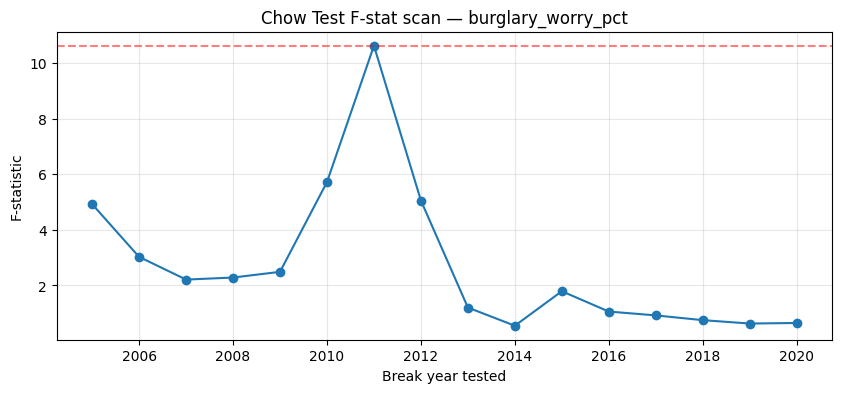

In [7]:
target_col = 'burglary_worry_pct'
s = df_annual[target_col].values.astype(float)

scan_years = df_annual['year'].values[3:-3]
scan_results = [(yr, *chow_test(s, y_arr, yr)) for yr in scan_years]
scan_df = pd.DataFrame(scan_results, columns=['break_year', 'F_stat', 'p_value'])

best = scan_df.loc[scan_df['F_stat'].idxmax()]
print(f'Most likely structural break in [{target_col}]: {int(best.break_year)}  '
      f'(F={best.F_stat}, p={best.p_value})')

plt.figure(figsize=(10, 4))
plt.plot(scan_df['break_year'], scan_df['F_stat'], marker='o')
plt.axhline(y=scan_df['F_stat'].max(), color='red', linestyle='--', alpha=0.5)
plt.title(f'Chow Test F-stat scan — {target_col}')
plt.xlabel('Break year tested'); plt.ylabel('F-statistic'); plt.grid(True, alpha=0.3)
plt.show()

Most likely structural break in [car_crime_worry_pct]: 2012  (F=79.4818, p=0.0)


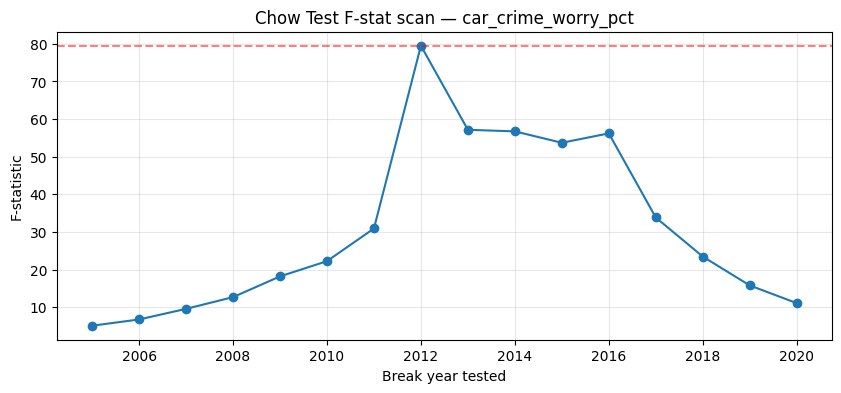

In [8]:
target_col = 'car_crime_worry_pct'
s = df_annual[target_col].values.astype(float)

scan_years = df_annual['year'].values[3:-3]
scan_results = [(yr, *chow_test(s, y_arr, yr)) for yr in scan_years]
scan_df = pd.DataFrame(scan_results, columns=['break_year', 'F_stat', 'p_value'])

best = scan_df.loc[scan_df['F_stat'].idxmax()]
print(f'Most likely structural break in [{target_col}]: {int(best.break_year)}  '
      f'(F={best.F_stat}, p={best.p_value})')

plt.figure(figsize=(10, 4))
plt.plot(scan_df['break_year'], scan_df['F_stat'], marker='o')
plt.axhline(y=scan_df['F_stat'].max(), color='red', linestyle='--', alpha=0.5)
plt.title(f'Chow Test F-stat scan — {target_col}')
plt.xlabel('Break year tested'); plt.ylabel('F-statistic'); plt.grid(True, alpha=0.3)
plt.show()

Most likely structural break in [violent_crime_worry_pct]: 2005  (F=9.7995, p=0.0013)


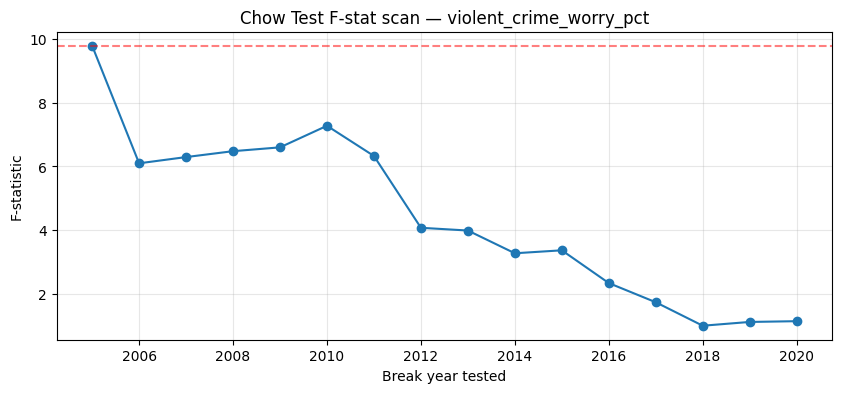

In [9]:
target_col = 'violent_crime_worry_pct'
s = df_annual[target_col].values.astype(float)

scan_years = df_annual['year'].values[3:-3]
scan_results = [(yr, *chow_test(s, y_arr, yr)) for yr in scan_years]
scan_df = pd.DataFrame(scan_results, columns=['break_year', 'F_stat', 'p_value'])

best = scan_df.loc[scan_df['F_stat'].idxmax()]
print(f'Most likely structural break in [{target_col}]: {int(best.break_year)}  '
      f'(F={best.F_stat}, p={best.p_value})')

plt.figure(figsize=(10, 4))
plt.plot(scan_df['break_year'], scan_df['F_stat'], marker='o')
plt.axhline(y=scan_df['F_stat'].max(), color='red', linestyle='--', alpha=0.5)
plt.title(f'Chow Test F-stat scan — {target_col}')
plt.xlabel('Break year tested'); plt.ylabel('F-statistic'); plt.grid(True, alpha=0.3)
plt.show()

Most likely structural break in [feel_safe_male_pct]: 2009  (F=3.1711, p=0.0661)


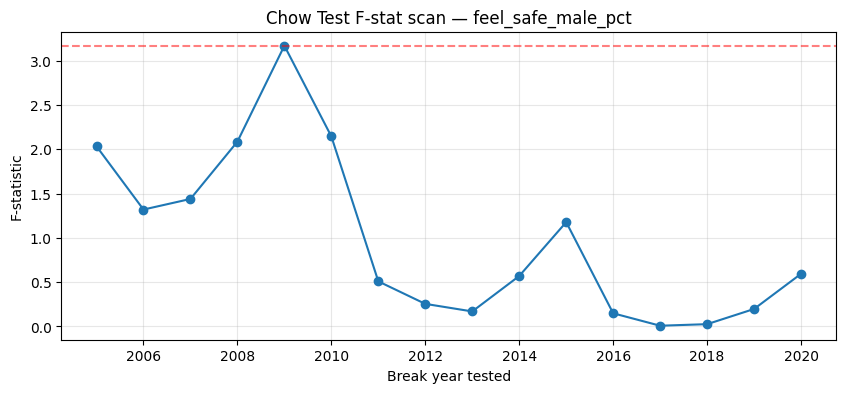

In [10]:
target_col = 'feel_safe_male_pct'
s = df_annual[target_col].values.astype(float)

scan_years = df_annual['year'].values[3:-3]
scan_results = [(yr, *chow_test(s, y_arr, yr)) for yr in scan_years]
scan_df = pd.DataFrame(scan_results, columns=['break_year', 'F_stat', 'p_value'])

best = scan_df.loc[scan_df['F_stat'].idxmax()]
print(f'Most likely structural break in [{target_col}]: {int(best.break_year)}  '
      f'(F={best.F_stat}, p={best.p_value})')

plt.figure(figsize=(10, 4))
plt.plot(scan_df['break_year'], scan_df['F_stat'], marker='o')
plt.axhline(y=scan_df['F_stat'].max(), color='red', linestyle='--', alpha=0.5)
plt.title(f'Chow Test F-stat scan — {target_col}')
plt.xlabel('Break year tested'); plt.ylabel('F-statistic'); plt.grid(True, alpha=0.3)
plt.show()

Most likely structural break in [feel_safe_female_pct]: 2012  (F=6.0814, p=0.0096)


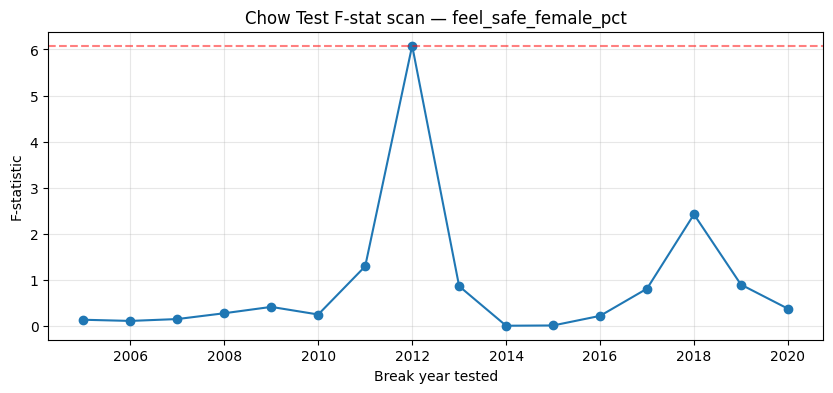

In [11]:
target_col = 'feel_safe_female_pct'
s = df_annual[target_col].values.astype(float)

scan_years = df_annual['year'].values[3:-3]
scan_results = [(yr, *chow_test(s, y_arr, yr)) for yr in scan_years]
scan_df = pd.DataFrame(scan_results, columns=['break_year', 'F_stat', 'p_value'])

best = scan_df.loc[scan_df['F_stat'].idxmax()]
print(f'Most likely structural break in [{target_col}]: {int(best.break_year)}  '
      f'(F={best.F_stat}, p={best.p_value})')

plt.figure(figsize=(10, 4))
plt.plot(scan_df['break_year'], scan_df['F_stat'], marker='o')
plt.axhline(y=scan_df['F_stat'].max(), color='red', linestyle='--', alpha=0.5)
plt.title(f'Chow Test F-stat scan — {target_col}')
plt.xlabel('Break year tested'); plt.ylabel('F-statistic'); plt.grid(True, alpha=0.3)
plt.show()

Most likely structural break in [feel_safe_all_pct]: 2012  (F=3.3705, p=0.0571)


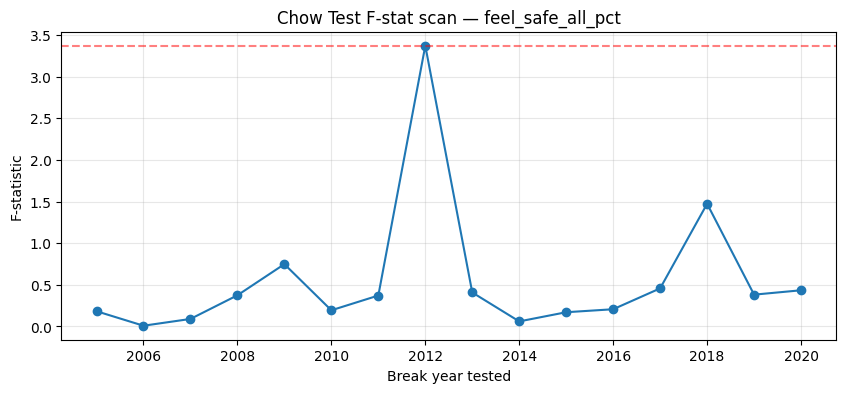

In [12]:
target_col = 'feel_safe_all_pct'
s = df_annual[target_col].values.astype(float)

scan_years = df_annual['year'].values[3:-3]
scan_results = [(yr, *chow_test(s, y_arr, yr)) for yr in scan_years]
scan_df = pd.DataFrame(scan_results, columns=['break_year', 'F_stat', 'p_value'])

best = scan_df.loc[scan_df['F_stat'].idxmax()]
print(f'Most likely structural break in [{target_col}]: {int(best.break_year)}  '
      f'(F={best.F_stat}, p={best.p_value})')

plt.figure(figsize=(10, 4))
plt.plot(scan_df['break_year'], scan_df['F_stat'], marker='o')
plt.axhline(y=scan_df['F_stat'].max(), color='red', linestyle='--', alpha=0.5)
plt.title(f'Chow Test F-stat scan — {target_col}')
plt.xlabel('Break year tested'); plt.ylabel('F-statistic'); plt.grid(True, alpha=0.3)
plt.show()